In [86]:
import pandas as pd
import sys
sys.path.append('../')
sys.path.append('dataset')
from utils import load_data, get_ssatd, get_satd
from tqdm import tqdm

def check_code_for_pattern(data, patterns):
    for pattern in patterns:
        regex = re.compile("({})".format(pattern), re.IGNORECASE)
        matches = regex.findall(data)
        if len(matches) > 0:
            return True

    return False

path = "<path>"
projects = ["weaksatd", "big-vul", "devign"]

data_weaksatd = load_data("{}/{}/complete.csv".format(path, projects[0]))
data_big_vul = load_data("{}/{}/complete.csv".format(path, projects[1]))
data_devign = load_data("{}/{}/complete.csv".format(path, projects[2]))

Load csv...: 689it [00:07, 86.99it/s] 
Load csv...: 145it [00:02, 54.53it/s]
Load csv...: 28it [00:01, 23.69it/s]


In [2]:
data_devign_FFmpeg = data_devign[data_devign["Project"] == "FFmpeg"]
data_big_vul_FFmpeg = data_big_vul[data_big_vul["Project"] == "FFmpeg"]

data_weaksatd_linux = data_weaksatd[data_weaksatd["Project"] == "Linux Kernel"]
data_big_vul_linux = data_big_vul[data_big_vul["Project"] == "linux"]

data_weaksatd_chromium = data_weaksatd[data_weaksatd["Project"] == "Chromium"]
data_big_vul_chromium = data_big_vul[data_big_vul["Project"] == "Chrome"]

print("Devign - FFmpeg: "+str(len(data_devign_FFmpeg)))
print("Big-Vul - FFmpeg: "+str(len(data_big_vul_FFmpeg)))
print("WeakSATD - Linux: "+str(len(data_weaksatd_linux)))
print("Big-Vul - Linux: "+str(len(data_big_vul_linux)))
print("WeakSATD - Chromium: "+str(len(data_weaksatd_chromium)))
print("Big-Vul - Chromium: "+str(len(data_big_vul_chromium)))

Devign - FFmpeg: 9769
Big-Vul - FFmpeg: 1932
WeakSATD - Linux: 652802
Big-Vul - Linux: 46855
WeakSATD - Chromium: 20062
Big-Vul - Chromium: 77173


In [3]:
import os
def check_and_create_folder(folder_name):
    current_path = os.getcwd()
    folder_path = os.path.join(current_path, folder_name)

    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"The folder {folder_name} has been created in the current path.")
    else:
        print(f"The folder {folder_name} already exists in the current path.")

check_and_create_folder("FFmpeg")
check_and_create_folder("Linux")
check_and_create_folder("Chromium")

The folder FFmpeg already exists in the current path.
The folder Linux already exists in the current path.
The folder Chromium already exists in the current path.


In [4]:
from tqdm import tqdm
import math

def merge_f_lc(row):
    if isinstance(row["LeadingComment"], float) and math.isnan(row["LeadingComment"]):
        return row["Function"]

    return "\n".join([row["LeadingComment"],row["Function"]])


def merge_function_with_leading_comment(data, key = "FunctionWithLeadingComment"):
    tqdm.pandas(total=len(data), desc="Merging Function and Leading Comment...")
    data[key] = data.progress_apply(merge_f_lc, axis=1)

    return data

def write_into_files(data, project, dataset):
    data = data.progress_apply(merge_function_with_leading_comment)
    pbar = tqdm(total=len(data), desc="Writing the files for the project {} of the dataset {}".format(project, dataset))
    for idx, row in data.iterrows():
        filename = "{}/{}_{}.c".format(project, dataset, idx)
        data = row["FunctionWithLeadingComment"]

        with open(filename, 'w') as file:
                file.write(data)
        pbar.update(1)

    pbar.close()

#write_into_files(data_devign_FFmpeg, "FFmpeg", "devign")
#write_into_files(data_big_vul_FFmpeg, "FFmpeg", "big-vul")
#write_into_files(data_weaksatd_linux, "linux_weaksatd", "weaksatd")
#write_into_files(data_big_vul_linux, "linux_big_vul", "big-vul")
#write_into_files(data_weaksatd_chromium, "chromium", "weaksatd")
#write_into_files(data_big_vul_chromium, "chromium", "big-vul")


In [40]:
def load_data_custom(path):

    # You can also create a DataFrame with columns if needed
    columns = ['lines', 'tokens', 'start', 'file', 'id']
    df = pd.DataFrame(columns=columns)

    pbar = tqdm(desc="Loading data..."+path)

    with open("dataset/extracted_projects/duplication_report/{}".format(path), 'r') as file:
        # Iterate over each line in the file
        idx = 0
        for line in file:
            if idx != 0:
                pbar.update(1)
                # Do something with each line, for example, print it
                split_line = line.strip().split(",")
                lines = int(split_line[0])
                tokens = int(split_line[1])
                occurrences = int(split_line[2])
                for idx_occurrences in range(occurrences):
                    start = int(split_line[3+idx_occurrences*2])
                    file = split_line[4+idx_occurrences*2]

                    df.loc[len(df)] = {
                        "lines": lines,
                        "tokens": tokens,
                        "start": start,
                        "file": file,
                        "id": idx
                    }

            idx += 1

    df['project'] = df['file'].str.extract(r'(devign|big-vul|weaksatd|big_vul)')
    return df

#Android_30 = load_data_custom("Android_duplication_30.csv")    #  10s
#chromium_30 = load_data_custom("chromium_duplication_30.csv")  #  113s
#FFmpeg_30 = load_data_custom("FFmpeg_duplication_30.csv")     #  82s
#file_30 = load_data_custom("file_duplication_30.csv")  # 0s
#ImageMagick_30 = load_data_custom("ImageMagick_duplication_30.csv")  # 85s
#kbr5_30 = load_data_custom("kbr5_duplication_30.csv")  # 0s
#Mozilla_Firefox_30 = load_data_custom("Mozilla_Firefox_duplication_30.csv")  # 8s
#php_30 = load_data_custom("php_duplication_30.csv")  # 4s
#QEMU_30 = load_data_custom("qemu_duplication_30.csv")    # 53s
#radare2_30 = load_data_custom("radare2_duplication_30.csv")    # 0s
#tcpdump_30 = load_data_custom("tcpdump_duplication_30.csv")    # 1s
#FFmpeg_60 = load_data_custom("FFmpeg_duplication_60.csv")
#Linux_30 = load_data_custom("Linux_duplication_30.csv")   # 1h31m32s
#QEMU_30 = load_data_custom("qemu_duplication_30.csv")    # 60s - 6.7MB

Loading data...Android_duplication_30.csv: 6071it [00:09, 647.48it/s]
Loading data...file_duplication_30.csv: 505it [00:00, 738.85it/s] 
Loading data...ImageMagick_duplication_30.csv: 13840it [01:14, 185.44it/s]
Loading data...kbr5_duplication_30.csv: 806it [00:00, 1044.61it/s]
Loading data...php_duplication_30.csv: 4109it [00:04, 845.60it/s] 
Loading data...radare2_duplication_30.csv: 880it [00:00, 940.05it/s] 
Loading data...tcpdump_duplication_30.csv: 954it [00:01, 710.81it/s] 


In [59]:
def add_percentage(df, multiple_project = True):
    df['Project_Count'] = df.groupby('id')['project'].transform('nunique')

    # Filter rows where the ID has more than one unique project
    if multiple_project:
        df = df[df['Project_Count'] > 1].drop(columns='Project_Count')
    else:
        df = df[df['Project_Count'] == 1].drop(columns='Project_Count')

    pbar = tqdm(total=len(df), desc="Calculating length of files...")

    # Display the result
    df["LOC"] = 0
    df["percentage"] = 0
    df["JACCARD"] = 0
    for idx, row in df.iterrows():
        file = row["file"]
        if "extracted_projects" not in file:
            file = file.replace("dataset", "dataset/extracted_projects")

        with open(file, 'r') as file:
            # Read the entire content
            content = file.read()
            LOC = len(content.split("\n"))
            df.loc[idx, "LOC"] = LOC
        pbar.update(1)

    pbar.close()

    pbar = tqdm(total=len(df), desc="Calculating percentage...")

    for idx, row in df.iterrows():
        id = row["id"]
        LOC = row["LOC"]
        tokens = row["tokens"]
        lines = row["lines"] if LOC > max(df[(df["id"] == id) & (df["tokens"] == tokens)]["lines"].tolist()) else LOC
        start_a = row["start"]
        lines_a = row["lines"]
        start_b = df[(df["id"] == id) & (df.index != idx)].sort_values(by='lines', ascending=False)["start"].tolist()[0]
        lines_b = df[(df["id"] == id) & (df.index != idx)].sort_values(by='lines', ascending=False)["lines"].tolist()[0]
        LOC_b = df[(df["id"] == id) & (df.index != idx)].sort_values(by='lines', ascending=False)["LOC"].tolist()[0]

        # Lines of code for each row
        range_A = set(range(start_a, lines_a))
        range_B = set(range(start_b, lines_b))
        range_A_1 = set(range(1, LOC))
        range_B_1 = set(range(1, LOC_b))
        intersection = len(range_A.intersection(range_B))
        union = len(range_A_1.union(range_B_1))

        # Calculate Jaccard index
        jaccard_index = intersection / union * 100 if union != 0 else 0

        df.loc[idx, "JACCARD"] = jaccard_index

        if row["project"] == "devign":
            percentage = lines/(LOC/2) * 100
            #print(LOC, lines)
            #print(LOC, row["lines"])
            #print(percentage)
            if percentage > 100:
                percentage = lines/(LOC/1) * 100
            #print(percentage)
            #print(len(content.split("\n")))
            #print("-------------" + str(row["id"]))
            df.loc[idx, "percentage"] = percentage
        else:
            df.loc[idx, "percentage"] = lines/LOC * 100
        pbar.update(1)

    pbar.close()

    return df

#Linux_30_multiple_projects = add_percentage(Linux_30, True)
#FFmpeg_30_multiple_projects = add_percentage(FFmpeg_30, True)
#chromium_30_multiple_projects = add_percentage(chromium_30, True)
#chromium_30_single_project = add_percentage(chromium_30, False)
#FFmpeg_30_single_project = add_percentage(FFmpeg_30, False)
#Linux_30_single_project = add_percentage(Linux_30, False)
#QMEU_30_single_project = add_percentage(QEMU_30, False)
#tcpdump_30_single_project = add_percentage(tcpdump_30, False)

Calculating percentage...: 100%|██████████| 67090/67090 [01:25<00:00, 784.25it/s]


In [60]:
QMEU_30_single_project.to_csv('QMEU_30_single_project.csv', index=False)

In [150]:
import re

def get_relevant_files(df):
    df = df[df["JACCARD"] > 99]
    df.drop_duplicates(subset=['id'], keep='first', inplace=True)
    df['project_id'] = df['file'].str.extract(r'(\d+)\.c$', flags=re.IGNORECASE)
    return df

Android_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/Android_30_single_project.csv"))
FFmpeg_30_multiple_projects = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/FFmpeg_30_multiple_projects.csv"))
FFmpeg_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/FFmpeg_30_single_project.csv"))
ImageMagick_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/ImageMagick_30_single_project.csv"))
Linux_30_multiple_projects = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/Linux_30_multiple_projects.csv"))
Linux_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/Linux_30_single_project.csv"))
Mozilla_Firefox_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/Mozilla_Firefox_30_single_project.csv"))
QMEU_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/QMEU_30_single_project.csv"))
chromium_30_multiple_projects = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/chromium_30_multiple_projects.csv"))
chromium_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/chromium_30_single_project.csv"))
file_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/file_30_single_project.csv"))
kbr5_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/kbr5_30_single_project.csv"))
php_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/php_30_single_project.csv"))
radare2_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/radare2_30_single_project.csv"))
tcpdump_30_single_project = get_relevant_files(load_data("dataset/extracted_projects/duplicate_dumps/tcpdump_30_single_project.csv"))

Load csv...: 21it [00:00, 75.92it/s]
/var/folders/vy/1_ps96bj3vn81l5_z37hplc80000gn/T/ipykernel_65554/3656484684.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(subset=['id'], keep='first', inplace=True)
/var/folders/vy/1_ps96bj3vn81l5_z37hplc80000gn/T/ipykernel_65554/3656484684.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['project_id'] = df['file'].str.extract(r'(\d+)\.c$', flags=re.IGNORECASE)
Load csv...: 18it [00:00, 766.54it/s]
/var/folders/vy/1_ps96bj3vn81l5_z37hplc80000gn/T/ipykernel_65554/3656484684.py:5: SettingWithCopyWa

In [152]:
Android_30_single_project

,lines,tokens,start,file,id,project,LOC,percentage,JACCARD,project_id
2,1162,5755,1,/Users/moritzmock/PycharmProjects/masked-satd/...,2,big_vul,1163,99.914015,99.828031,56983
31,771,2850,1,/Users/moritzmock/PycharmProjects/masked-satd/...,13,big_vul,772,99.870466,99.740933,59770
33,763,2821,1,/Users/moritzmock/PycharmProjects/masked-satd/...,14,big_vul,764,99.869110,99.738220,59762
35,582,2769,1,/Users/moritzmock/PycharmProjects/masked-satd/...,15,big_vul,583,99.828473,99.656947,62005
37,582,2763,1,/Users/moritzmock/PycharmProjects/masked-satd/...,16,big_vul,583,99.828473,99.656947,62006
139,306,1329,1,/Users/moritzmock/PycharmProjects/masked-satd/...,54,big_vul,307,99.674267,99.025974,61229
141,329,1326,1,/Users/moritzmock/PycharmProjects/masked-satd/...,55,big_vul,330,99.696970,99.393939,64413
145,344,1306,1,/Users/moritzmock/PycharmProjects/masked-satd/...,57,big_vul,345,99.710145,99.709302,64438
199,305,1042,1,/Users/moritzmock/PycharmProjects/masked-satd/...,77,big_vul,306,99.673203,99.346405,60907
205,213,1029,1,/Users/moritzmock/PycharmProjects/masked-satd/...,79,big_vul,214,99.532710,99.530516,61851


In [153]:
data_big_vul[(data_big_vul["Project"] == "Android") & (data_big_vul.index == 56983)]["FunctionWithComments"]

56983    status_t MPEG4Extractor::parseChunk(off64_t *o...
Name: FunctionWithComments, dtype: object

In [184]:
def remove_by_ID(data, JACCARD):
    for idx, row in JACCARD.iterrows():
        id = int(row["project_id"])
        if id in data.index:
            data.drop([id], inplace=True)
    return data

data_big_vul_copy = data_big_vul.copy(deep=True)
data_big_vul_copy = remove_by_ID(data_big_vul_copy, Android_30_single_project)
print("andorid-{} - {} ({})".format(len(data_big_vul), len(data_big_vul_copy), len(data_big_vul) - len(data_big_vul_copy)))
data_big_vul_copy = remove_by_ID(data_big_vul_copy, file_30_single_project)
print("file-{} - {} ({})".format(len(data_big_vul), len(data_big_vul_copy), len(data_big_vul) - len(data_big_vul_copy)))
data_big_vul_copy = remove_by_ID(data_big_vul_copy, ImageMagick_30_single_project)
print("image-{} - {} ({})".format(len(data_big_vul), len(data_big_vul_copy), len(data_big_vul) - len(data_big_vul_copy)))
data_big_vul_copy = remove_by_ID(data_big_vul_copy, kbr5_30_single_project)
print("kbr-{} - {} ({})".format(len(data_big_vul), len(data_big_vul_copy), len(data_big_vul) - len(data_big_vul_copy)))
data_big_vul_copy = remove_by_ID(data_big_vul_copy, php_30_single_project)
print("php-{} - {} ({})".format(len(data_big_vul), len(data_big_vul_copy), len(data_big_vul) - len(data_big_vul_copy)))
data_big_vul_copy = remove_by_ID(data_big_vul_copy, radare2_30_single_project)
print("radare-{} - {} ({})".format(len(data_big_vul), len(data_big_vul_copy), len(data_big_vul) - len(data_big_vul_copy)))
data_big_vul_copy = remove_by_ID(data_big_vul_copy, tcpdump_30_single_project)
print("tcp-{} - {} ({})".format(len(data_big_vul), len(data_big_vul_copy), len(data_big_vul) - len(data_big_vul_copy)))

data_big_vul_copy = remove_by_ID(data_big_vul_copy, Linux_30_single_project[Linux_30_single_project["project"] == "big-vul"])
print("linux-{} - {} ({})".format(len(data_big_vul), len(data_big_vul_copy), len(data_big_vul) - len(data_big_vul_copy)))
#data_big_vul_copy = remove_by_ID(data_big_vul_copy, Linux_30_multiple_projects[Linux_30_multiple_projects["project"] == "big-vul"])
data_big_vul_copy = remove_by_ID(data_big_vul_copy, FFmpeg_30_single_project[FFmpeg_30_single_project["project"] == "big-vul"])
print("ffmpeg-{} - {} ({})".format(len(data_big_vul), len(data_big_vul_copy), len(data_big_vul) - len(data_big_vul_copy)))
#data_big_vul_copy = remove_by_ID(data_big_vul_copy, FFmpeg_30_multiple_projects[FFmpeg_30_multiple_projects["project"] == "big-vul"])
data_big_vul_copy = remove_by_ID(data_big_vul_copy, chromium_30_single_project[chromium_30_single_project["project"] == "big-vul"])
print("cromium-{} - {} ({})".format(len(data_big_vul), len(data_big_vul_copy), len(data_big_vul) - len(data_big_vul_copy)))
#data_big_vul_copy = remove_by_ID(data_big_vul_copy, chromium_30_multiple_projects[chromium_30_multiple_projects["project"] == "big-vul"])

#data_big_vul_copy.to_csv("data_final_without_duplicates/big-vul/complete.csv", index=False)

print("{} - {} ({})".format(len(data_big_vul), len(data_big_vul_copy), len(data_big_vul) - len(data_big_vul_copy)))

#data_devign_copy = data_devign.copy(deep=True)
#data_devign_copy = remove_by_ID(data_devign_copy, QMEU_30_single_project)

#data_devign_copy = remove_by_ID(data_devign_copy, FFmpeg_30_single_project[FFmpeg_30_single_project["project"] == "devign"])
#data_devign_copy = remove_by_ID(data_devign_copy, FFmpeg_30_multiple_projects[FFmpeg_30_multiple_projects["project"] == "devign"])

#data_devign_copy.to_csv("data_final_without_duplicates/devign/complete.csv", index=False)

#print("{} - {} ({})".format(len(data_devign), len(data_devign_copy), len(data_devign) - len(data_devign_copy)))

#data_weaksatd_copy = data_weaksatd.copy(deep=True)
#data_weaksatd_copy = remove_by_ID(data_weaksatd_copy, Mozilla_Firefox_30_single_project)

#data_weaksatd_copy = remove_by_ID(data_weaksatd_copy, chromium_30_single_project[chromium_30_single_project["project"] == "weaksatd"])
#data_weaksatd_copy = remove_by_ID(data_weaksatd_copy, chromium_30_multiple_projects[chromium_30_multiple_projects["project"] == "weaksatd"])
#data_weaksatd_copy = remove_by_ID(data_weaksatd_copy, Linux_30_single_project[Linux_30_single_project["project"] == "weaksatd"])
#data_weaksatd_copy = remove_by_ID(data_weaksatd_copy, Linux_30_multiple_projects[Linux_30_multiple_projects["project"] == "weaksatd"])

#data_weaksatd_copy.to_csv("data_final_without_duplicates/weaksatd/complete.csv", index=False)

#print("{} - {} ({})".format(len(data_weaksatd), len(data_weaksatd_copy), len(data_weaksatd) - len(data_weaksatd_copy)))

andorid-144485 - 144467 (18)
file-144485 - 144461 (24)
image-144485 - 144430 (55)
kbr-144485 - 144428 (57)
php-144485 - 144417 (68)
radare-144485 - 144413 (72)
tcp-144485 - 144398 (87)
linux-144485 - 144371 (114)
ffmpeg-144485 - 144366 (119)
cromium-144485 - 144360 (125)
144485 - 144360 (125)


In [162]:
len(FFmpeg_30_multiple_projects)

2

In [139]:
data_weaksatd_copy[(data_weaksatd_copy["Project"] == "Mozilla Firefox") & (data_weaksatd_copy.index == 34048)]

,Unnamed: 0,FunctionWithComments,Comments,FunctionWithoutComments,Project,CommitID,Filename,SATD,Vulnerable,Class,HasComments


In [140]:
data_weaksatd_copy[(data_weaksatd_copy["Project"] == "Mozilla Firefox")]

,Unnamed: 0,FunctionWithComments,Comments,FunctionWithoutComments,Project,CommitID,Filename,SATD,Vulnerable,Class,HasComments
20062,20062,\n/**\n * Return true if the loaded version of...,/**\n * Return true if the loaded version of l...,\n\nstatic inline bool IsAtkVersionAtLeast(int...,Mozilla Firefox,4d46db3ff28b,accessible/atk/nsMai.h,0,1,2.0,1.0
20063,20063,"\nuint32_t RowExtentAt(uint32_t aRowIdx, uint3...",// Verify that the cell's Accessible is valid.,"\nuint32_t RowExtentAt(uint32_t aRowIdx, uint3...",Mozilla Firefox,4d46db3ff28b,accessible/base/CachedTableAccessible.h,0,0,0.0,1.0
20064,20064,\nvirtual int32_t CellIndexAt(uint32_t aRowIdx...,NaN,\nvirtual int32_t CellIndexAt(uint32_t aRowIdx...,Mozilla Firefox,4d46db3ff28b,accessible/base/CachedTableAccessible.h,0,0,0.0,0.0
20065,20065,\nvirtual bool IsColSelected(uint32_t aColIdx)...,NaN,\nvirtual bool IsColSelected(uint32_t aColIdx)...,Mozilla Firefox,4d46db3ff28b,accessible/base/CachedTableAccessible.h,0,0,0.0,0.0
20066,20066,\nvirtual bool IsRowSelected(uint32_t aRowIdx)...,NaN,\nvirtual bool IsRowSelected(uint32_t aRowIdx)...,Mozilla Firefox,4d46db3ff28b,accessible/base/CachedTableAccessible.h,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
35444,35444,\n/* See testValueABI.cpp */\n\nbool C_ValueTo...,/* See testValueABI.cpp */,"\n\n\nbool C_ValueToObject(JSContext* cx, jsva...",Mozilla Firefox,4d46db3ff28b,js/src/jsapi-tests/valueABI.c,0,0,0.0,1.0
35445,35445,\njsval C_GetEmptyStringValue(JSContext* cx) {...,NaN,\njsval C_GetEmptyStringValue(JSContext* cx) {...,Mozilla Firefox,4d46db3ff28b,js/src/jsapi-tests/valueABI.c,0,0,0.0,0.0
35446,35446,\nsize_t C_jsvalAlignmentTest() {\n typedef s...,NaN,\nsize_t C_jsvalAlignmentTest() {\n typedef s...,Mozilla Firefox,4d46db3ff28b,js/src/jsapi-tests/valueABI.c,0,1,2.0,0.0
35447,35447,\n// Returns the key for the class inherited b...,// Returns the key for the class inherited by ...,\n\n\n\n You must be sure that this correspond...,Mozilla Firefox,4d46db3ff28b,js/src/jsfriendapi.h,0,0,0.0,1.0


In [11]:
# Unique files affected by the duplication
#print(len(FFmpeg_120["file"].unique()), "file are affected of duplication from FFmpeg, out of which", len(FFmpeg_120[FFmpeg_120["project"] == "big-vul"]["file"].unique()), "are from Big-Vul and", len(FFmpeg_120[FFmpeg_120["project"] == "devign"]["file"].unique()), "from Devign")

#print("Which corresponds to {} percent for FFmpeg/Devign".format(round(len(FFmpeg_120[FFmpeg_120["project"] == "devign"]["file"].unique())/len(data_devign_FFmpeg), 3)))
#print("Which corresponds to {} percent for FFmpeg/Big-Vul".format(round(len(FFmpeg_120[FFmpeg_120["project"] == "big-vul"]["file"].unique())/len(data_big_vul_FFmpeg), 3)))
#print("")

#print(len(Linux_120["file"].unique()), "file are affected of duplication from FFmpeg, out of which", len(Linux_120[Linux_120["project"] == "big-vul"]["file"].unique()), "are from Big-Vul and", len(Linux_120[Linux_120["project"] == "weaksatd"]["file"].unique()), "from WeakSATD")

#print("Which corresponds to {} percent for Linux/WeakSATD".format(round(len(Linux_120[Linux_120["project"] == "weaksatd"]["file"].unique())/len(data_weaksatd_linux), 3)))
#print("Which corresponds to {} percent for Linux/Big-Vul".format(round(len(Linux_120[Linux_120["project"] == "big-vul"]["file"].unique())/len(data_big_vul_linux), 3)))
#print("")

In [19]:
import matplotlib.pyplot as plt
import numpy as np

In [59]:
def make_histogram(df, title):

    data = df["percentage"].tolist()

    plt.hist(data, bins=np.arange(min(data), max(data) + 1.5) - 0.5, edgecolor='black')
    plt.title(title)
    plt.xlabel('Percentages')
    plt.ylabel('Count')

    # Show the plot
    plt.show()

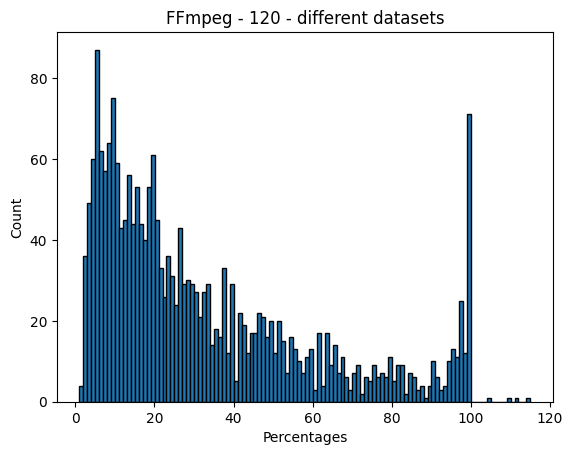

In [60]:
make_histogram(FFmpeg_120_multiple_projects, "FFmpeg - 120 - different datasets")

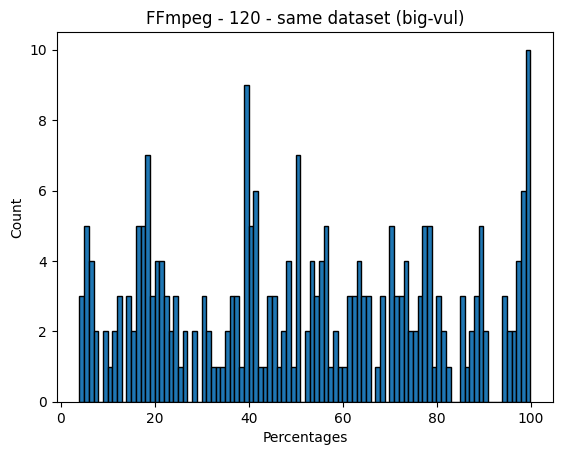

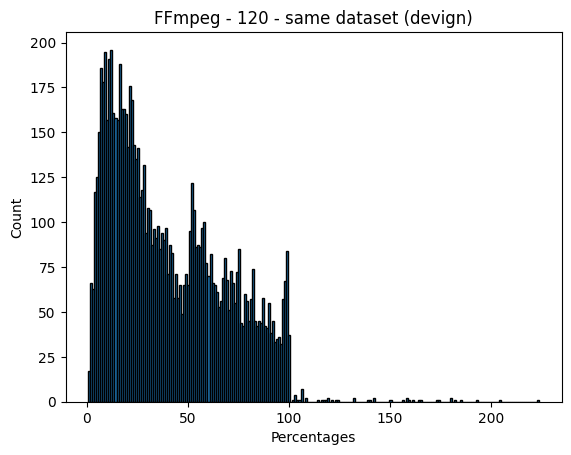

In [61]:
make_histogram(FFmpeg_120_single_project[FFmpeg_120_single_project["project"] == "big-vul"], "FFmpeg - 120 - same dataset (big-vul)")
make_histogram(FFmpeg_120_single_project[FFmpeg_120_single_project["project"] == "devign"], "FFmpeg - 120 - same dataset (devign)")

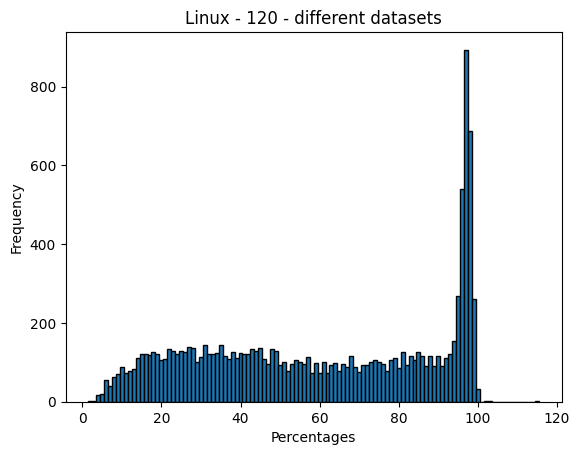

In [27]:
make_histogram(Linux_120_multiple_projects, "Linux - 120 - different datasets")

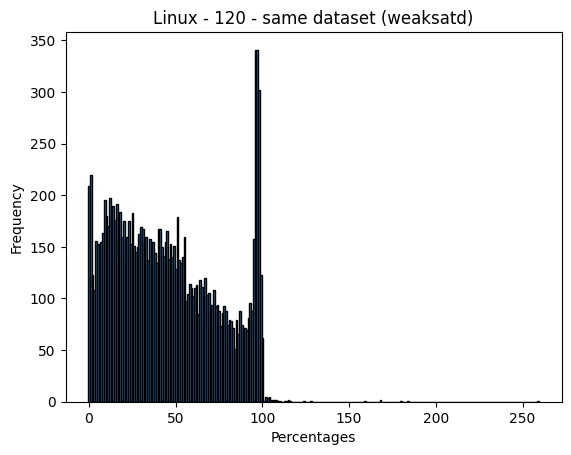

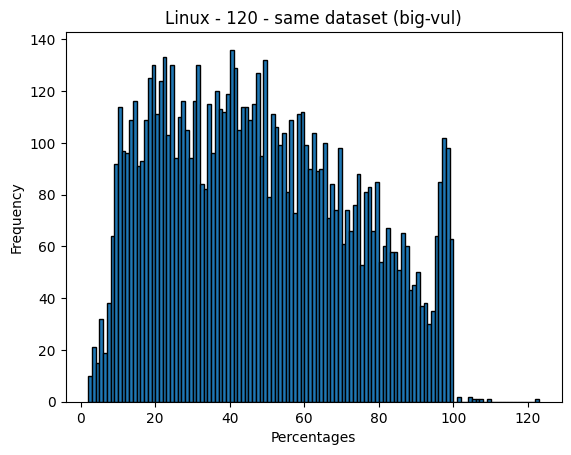

In [29]:
make_histogram(Linux_120_single_project[Linux_120_single_project["project"] == "weaksatd"], "Linux - 120 - same dataset (weaksatd)")
make_histogram(Linux_120_single_project[Linux_120_single_project["project"] == "big-vul"], "Linux - 120 - same dataset (big-vul)")